In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1024.5), np.float64(560.5), np.float64(-0.5))

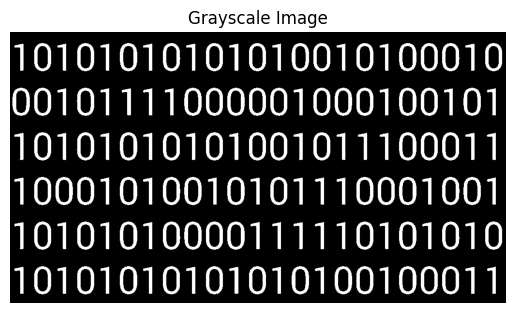

In [7]:
img = cv2.imread("/kaggle/input/datasets/arahul22/ee655-q4-data/binl.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1024.5), np.float64(560.5), np.float64(-0.5))

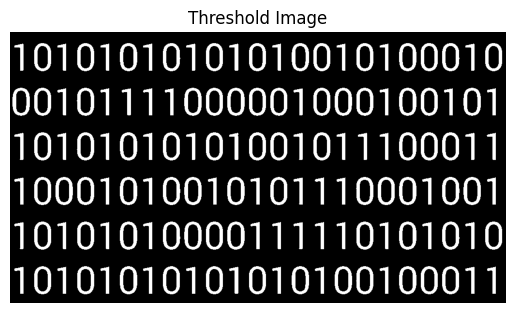

In [8]:
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")

In [9]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh)

print("Total components detected:", num_labels)

Total components detected: 139


In [10]:
boxes = []

for i in range(1, num_labels):   # skip background
    
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]
    
    if area > 100:
        boxes.append((x,y,w,h))

print("Digits detected:", len(boxes))

Digits detected: 138


(np.float64(-0.5), np.float64(1024.5), np.float64(560.5), np.float64(-0.5))

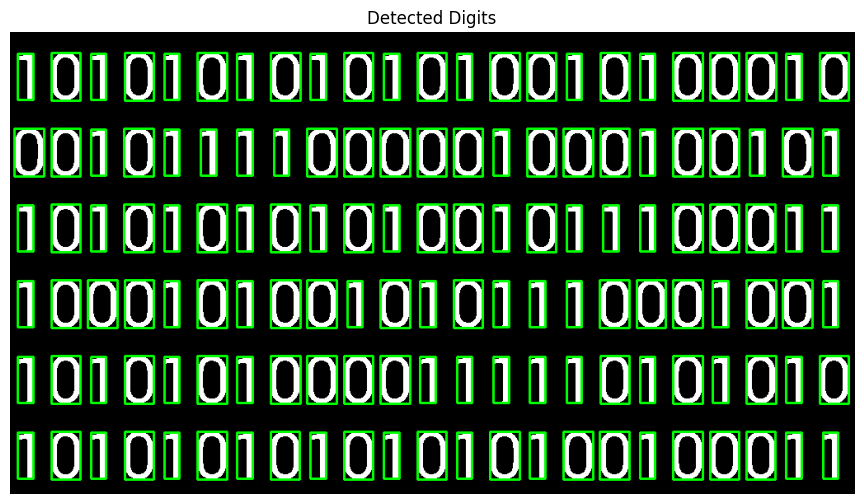

In [11]:
img_copy = img.copy()

for (x,y,w,h) in boxes:
    
    cv2.rectangle(img_copy,(x,y),(x+w,y+h),(0,255,0),2)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Detected Digits")
plt.axis("off")

In [12]:
boxes = sorted(boxes, key=lambda b:(b[1], b[0]))

rows=[]
current=[boxes[0]]

for b in boxes[1:]:
    
    if abs(b[1]-current[0][1]) < 20:
        current.append(b)
    else:
        rows.append(sorted(current, key=lambda r:r[0]))
        current=[b]

rows.append(sorted(current, key=lambda r:r[0]))

print("Rows detected:", len(rows))

Rows detected: 6


In [13]:
results=[]

for row in rows:
    
    binary=""
    
    for (x,y,w,h) in row:
        
        if w < h*0.5:
            digit="1"
        else:
            digit="0"
            
        binary += digit
        
    results.append(binary)

In [14]:
print("Extracted Binary Numbers:\n")

for r in results:
    print(r)

Extracted Binary Numbers:

10101010101010010100010
00101111000001000100101
10101010101001011100011
10001010010101110001001
10101010000111110101010
10101010101010100100011
